## 비교군 : Agglomorative

### 라이브러리 호출

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

### 한글 폰트 설정 (운영체체에 맞게 설정)

In [2]:
import platform
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

### Step1 : 데이터 준비 및 전처리

In [3]:
# 데이터 불러오기 (추출한 9개의 변수)
df = pd.read_csv('single variable_data.csv')
surviving_cols = [
    'risk_depression', 'risk_iadl', 'risk_nutrition', 'risk_suicide', 'risk_smoke',
    'risk_meet', 'risk_network', 'risk_subj_econ', 'risk_housing_tenure'
]

surviving_cols_std = [col + '_std' for col in surviving_cols]
X_scaled = df[surviving_cols_std]
print(f"학습용 데이터 준비 완료: {X_scaled.shape}")

학습용 데이터 준비 완료: (3448, 9)


### Step2 : 덴드로그램(Dendrogram) 시각화

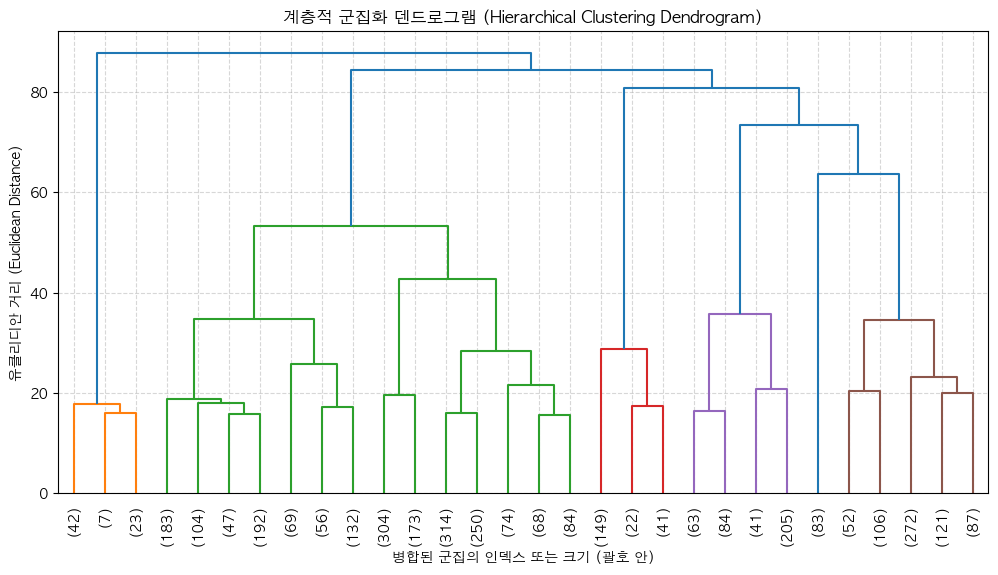

In [4]:
# 계층적 군집화 연결(Linkage) 수행 
# (Ward 방식: 군집 내 분산을 가장 적게 증가시키는 방향으로 병합하는 정석 방식)
linked = linkage(X_scaled, method='ward')

# 덴드로그램 그리기 (데이터가 많아 복잡하므로 마지막 5단계 병합까지만 요약해서 출력)
plt.figure(figsize=(12, 6))
dendrogram(linked, truncate_mode='lastp', p=30, leaf_rotation=90., leaf_font_size=10.)
plt.title('계층적 군집화 덴드로그램 (Hierarchical Clustering Dendrogram)')
plt.xlabel('병합된 군집의 인덱스 또는 크기 (괄호 안)')
plt.ylabel('유클리디안 거리 (Euclidean Distance)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Step 3 : Agglomerative Clustering 모델 학습 (n_clusters=5)

In [5]:
# K-Means와 공정한 비교를 위해 군집 개수를 5개로 고정하여 학습
agg_model = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward')
df['agg_cluster'] = agg_model.fit_predict(X_scaled)

In [6]:
# 결과 출력 및 실루엣 스코어 계산
print("\n[Agglomerative 군집별 데이터 개수]")
print(df['agg_cluster'].value_counts().sort_index())

score = silhouette_score(X_scaled, df['agg_cluster'])
print(f"\n Agglomerative Clustering 실루엣 점수: {score:.4f}")


[Agglomerative 군집별 데이터 개수]
agg_cluster
0     721
1     393
2    2050
3      72
4     212
Name: count, dtype: int64

 Agglomerative Clustering 실루엣 점수: 0.2694
